In [2]:
import os
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# import matplotlib.colors as mpl_colors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap

from torchinfo import summary
import time
import sys
import pandas as pd
import sympy as sp
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol


from IPython.display import display, Math


import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib
def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
RUN_ID = 'SP'
DT = 1
Q0 = 17921.57581 

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'tau': 10.0,
    'k':  0.01,
    's':  0.37266314,
    'sdot': 0.0001,
    'C': 5,
    'd': 30,
    }


VARIABLES = ['R0', 'R1', 'C1','k'] # ,'s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"



chosen_SR = {
    'R0': 8, # JN
    'R1': 8, # JH
    'C1': 7, # JN
    'k': 7, # JH
    's': 6 # JN
}
 
best_SR = {
    'R0': 19, # JN
    'R1': 19, # JH
    'C1': 24, # JN 
    'k': 22, # JH 
    's': 27 # JN
}



In [4]:
# model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'   # Same
# model_name = '0510_2034_combo_low_c_d_combo_V-dynamic_F-dynamic_702.38min_16h_2500eps.pt'
# model_name = '0511_0931_b4_softplus_combo_full_combo_V-dynamic_F-dynamic_504.37min_16h_2000eps.pt'
# model_name = '0508_2228_DC_DC_V-dynamic_F-dynamic_436.43min_16h_650eps.pt'
# model_name = '0514_0823_b4_combo_combo_V-dynamic_F-dynamic_R0c_C1c_708.27min_16h_2500eps.pt'  # Same
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'  # Softplus
#model_name = '0520_1111__b4_softplus_same__combo_V-dynamic_F-dynamic_unconstr_781.23min_16h_2500eps.pt' # Softplus, same seed as combo_full
BAT_MODEL, ckpt = load_nn_model(model_name)

df = Param_symbol.read_raw_data('combo_half')
trajs = prepare_data(df)

data = data_param(BAT_MODEL, trajs)
display(data)

def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


# def plot_element_sweep(model, element, sweep = 'u_per', fixed = 1, sweep_vals = None):
#     ''' If sweep 'u_per', then fixed_value is 'c_rate', and vice versa. '''

#     if sweep_vals is None:
#         if sweep == 'u_per':
#             sweep_vals = np.linspace(0,30,6)
#         else:
#             sweep_vals = np.array([0.5, 1, 2, 3, 4, 5])

#     soc = np.linspace(1.0, 0.1, 100)
#     soc_t = torch.as_tensor(soc, dtype=torch.float32)   # torch view for sdot loop

#     if sweep == 'u_per':
#         bar_label  = r'$\widetilde{d}$ [\%]'
#         fixed_tag    = fr'${fixed:g}$C'
#     elif sweep == 'c_rate':
#         bar_label  = 'C-rate [1/h]'
#         fixed_tag    = fr'$\widetilde{{d}} = {fixed:g}\%$'

#     META = {
#         'R0': (1e3,  r'$R_0$ [m$\Omega$]'),
#         'R1': (1e3,  r'$R_1$ [m$\Omega$]'),
#         'C1': (1e-3,  r'$C_1$ [kF]'),
#         'k':  (1e2,  r'$k$ [GN/mm]'),
#         'sdot':  (10, r'$\dot{s}$ [$\mu$m/s]'),
#         's':  (10, r'$s$ [$\mu$m]'),
#         'tau': (1.0, r'$\tau$ [s]'),
#     }
#     scale, ylabel = META[element]

#     norm = Normalize(vmin=sweep_vals.min(), vmax=sweep_vals.max())
#     base = plt.cm.Blues_r
#     Blues_cut = LinearSegmentedColormap.from_list("Blues_custom", base(np.linspace(0.0, 0.8, 256)))
#     cmap = Blues_cut

#     fig,ax = plt.subplots(figsize=(6,4.2))

#     NN = {'R0': R0_nn, 'R1': R1_nn, 'C1': C1_nn, 'k': k_nn}

#     for val in sweep_vals:
#         c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        
#         if element in NN:
#             y = NN[element](c_rate, u_per, soc_t)

#         elif element == 'tau':
#             R1 = R1_nn(c_rate, u_per, soc_t)
#             C1 = C1_nn(c_rate, u_per, soc_t)
#             y = R1 * C1
    
#         elif element == 'sdot':
#             # Forward-Euler integrate s along SOC, evaluating ds/dt at each step
#             s_curr = torch.zeros((), dtype=torch.float32)
#             ds_list = []

#             dsoc = float(abs(soc_t[1] - soc_t[0]))
#             dt = dsoc * 3600.0 / c_rate         # seconds per SOC step, then y is microm/s

#             for soc_val in soc_t:                   # single SOC at a time
#                 ds = sdot_nn(c_rate, u_per, soc_val, s_curr)   # numpy scalar
#                 ds_val = float(np.asarray(ds).squeeze())
#                 ds_list.append(ds_val)
#                 s_curr = s_curr + ds_val * dt
#             y = np.asarray(ds_list)

#         elif element == 's':
#             # Forward-Euler integrate s along SOC, evaluating ds/dt at each step
#             s_curr = torch.zeros((), dtype=torch.float32)
#             s_list = []

#             dsoc = float(abs(soc_t[1] - soc_t[0]))
#             dt = dsoc * 3600.0 / c_rate         # seconds per SOC step, then y is microm/s

#             for soc_val in soc_t:                   # single SOC at a time
#                 ds = sdot_nn(c_rate, u_per, soc_val, s_curr)   # numpy scalar
#                 ds_val = float(np.asarray(ds).squeeze())
#                 s_curr = s_curr + ds_val * dt
#                 s_list.append(s_curr.item())
#             y = np.asarray(s_list)
            

#         ax.plot(soc, y * scale, color=cmap(norm(val)), lw=2)


#     ax.set_xlabel('State of Charge')
#     ax.set_ylabel(ylabel)
#     ax.ticklabel_format(useOffset=False, style='plain', axis='y')
#     ax.invert_xaxis()
#     ax.set_title(f'{fixed_tag}')
#     sm = ScalarMappable(cmap=cmap, norm=norm)
#     fig.colorbar(sm, ax=ax, label=bar_label)
#     plt.tight_layout()

#     return fig

# # #Every element, both modes, save to FIGS_DIR
# # for elem in ['R0', 'R1', 'C1', 'tau', 'k', 'sdot', 's']:
# #     for sweep, fixed in [('u_per', 2.5), ('c_rate', 15.0)]:
# #         plot_element_sweep(BAT_MODEL, elem, sweep=sweep, fixed=fixed)
# #         plt.savefig(os.path.join('element_figs', f'{elem}_sweep-{sweep}_fix-{fixed:g}_{model_name}.pdf'))
# #         plt.show()

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.58,25.6,2.887365,-3.679552,1.000000,0.007677,11202.099609,0.013824,0.031672,0.000000,0.000004
1,0,0.58,25.6,2.887365,-3.679552,0.999839,0.007677,11202.101562,0.013819,0.031672,0.000004,0.000004
2,0,0.58,25.6,2.887365,-3.679552,0.999678,0.007677,11202.105469,0.013815,0.031673,0.000009,0.000004
3,0,0.58,25.6,2.887365,-3.679552,0.999517,0.007677,11202.107422,0.013810,0.031673,0.000013,0.000004
4,0,0.58,25.6,2.887365,-3.679552,0.999356,0.007677,11202.113281,0.013805,0.031674,0.000017,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...
241513,106,5.00,0.0,24.891078,0.000000,0.233333,0.288619,2423.203369,0.007863,0.023964,0.278996,0.000481
241514,106,5.00,0.0,24.891078,0.000000,0.231944,0.288632,2390.546143,0.007860,0.023967,0.279477,0.000481
241515,106,5.00,0.0,24.891078,0.000000,0.230556,0.288645,2359.334717,0.007857,0.023970,0.279958,0.000481
241516,106,5.00,0.0,24.891078,0.000000,0.229167,0.288658,2329.498779,0.007853,0.023974,0.280439,0.000481


In [5]:
df_CC = Param_symbol.read_raw_data('merged_DC_hyper')
df_CC = Param_symbol.read_raw_data('merged_pulse_hyper')
display(df_CC)

,u_par,C,t,V,F,u,Ue,soc,I,trajectory,eta
0,19.1,4.5,0,4.229418,0.078557,-2.745291,4.324996,0.999999,11.200985,0,0.095578
1,19.1,4.5,1,4.118165,0.078575,-2.745291,4.321218,0.998758,22.401970,0,0.203053
2,19.1,4.5,2,4.099471,0.078591,-2.745291,4.317412,0.997508,22.401970,0,0.217940
3,19.1,4.5,3,4.084324,0.078608,-2.745291,4.313605,0.996258,22.401970,0,0.229282
4,19.1,4.5,4,4.071481,0.078625,-2.745291,4.309799,0.995008,22.401970,0,0.238318
...,...,...,...,...,...,...,...,...,...,...,...
227346,17.2,2.5,2723,2.619369,0.080803,-2.472199,3.381726,0.096906,12.445539,74,0.762358
227347,17.2,2.5,2724,2.579749,0.080813,-2.472199,3.379533,0.096211,12.445539,74,0.799784
227348,17.2,2.5,2725,2.532106,0.080822,-2.472199,3.377339,0.095517,12.445539,74,0.845233
227349,17.2,2.5,2726,2.478750,0.080832,-2.472199,3.375146,0.094822,12.445539,74,0.896395


In [6]:
# Extract expressions from symbolic regression results
def extract_expressions(run_id):
    # Load the symbolic regression results
    elements = ['k', 'R1', 'C1', 'R0', 'sdot']#, 's']
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            results_path = Path(f'sr_models/model_s_{run_id}.csv')
            # raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format']# == int(results_df['complexity'].mean())]
        expressions[elem] = expr

    
    return expressions

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
#res, R0_expr, R1_expr, C1_expr, k_expr, s_expr = extract_expressions(RUN_ID)
expressions = extract_expressions(RUN_ID)
R0_expr = expressions['R0']
R1_expr = expressions['R1']
C1_expr = expressions['C1']
k_expr = expressions['k']
sdot_expr = expressions['sdot']

latent_variables = {'x0': 'c-rate', 'x1': 'd_per', 'x2': 'soc', 'x3':'s'}


from collections import Counter

symbol_counts = {}
for elem in VARIABLES:
    counter = Counter()
    for expr in expressions[elem]:
        sympy_expr = sp.sympify(expr)

        counter.update(map(str, sympy_expr.free_symbols))

    symbol_counts[elem] = counter

# convert to dataframe for better visualization
symbol_counts_df = pd.DataFrame(symbol_counts).fillna(0).astype(int)

for elem in symbol_counts_df:
    symbol_counts_df[elem] = 100 * symbol_counts_df[elem] / expressions[elem].shape[0]

df_symcounts = symbol_counts_df.transpose()
display(df_symcounts)
print(f'Latent variables: {latent_variables}')
df_symcounts.columns = [latent_variables.get(col, col) for col in df_symcounts.columns]
display(df_symcounts)

# round values to 1 decimal place
df_symcounts = df_symcounts.round(1)

def df_latex_table(df, caption=None, label=None):
    latex_str = df.to_latex(index=True, escape=False)
    if caption:
        latex_str = latex_str.replace('\\begin{tabular}', f'\\begin{{table}}[ht]\n\\centering\n\\caption{{{caption}}}\n\\begin{{tabular}}')
    if label:
        latex_str = latex_str.replace('\\end{tabular}', f'\\end{{tabular}}\n\\label{{{label}}}\n\\end{{table}}')
    return latex_str

latex_table = df_latex_table(df_symcounts, caption="Symbol usage percentages in SR expressions", label="tab:symbol_usage")
print(latex_table)


Loading symbolic regression results for RUN_ID: SP


,soc,C,d
R0,96.000000,80.000000,72.000000
R1,92.000000,84.000000,0.000000
C1,96.296296,77.777778,0.000000
k,78.260870,0.000000,95.652174


Latent variables: {'x0': 'c-rate', 'x1': 'd_per', 'x2': 'soc', 'x3': 's'}


,soc,C,d
R0,96.000000,80.000000,72.000000
R1,92.000000,84.000000,0.000000
C1,96.296296,77.777778,0.000000
k,78.260870,0.000000,95.652174


\begin{table}[ht]
\centering
\caption{Symbol usage percentages in SR expressions}
\begin{tabular}{lrrr}
\toprule
 & soc & C & d \\
\midrule
R0 & 96.000000 & 80.000000 & 72.000000 \\
R1 & 92.000000 & 84.000000 & 0.000000 \\
C1 & 96.300000 & 77.800000 & 0.000000 \\
k & 78.300000 & 0.000000 & 95.700000 \\
\bottomrule
\end{tabular}
\label{tab:symbol_usage}
\end{table}



In [7]:
def display_expresions(elem, latent_variables, expressions = expressions, complexity = None, ref_values = REF_VALUES):

    print(f"\nExpression for {elem}:")
    for j,expr in enumerate(expressions[elem]):
        sympy_expr = sp.sympify(expr)
        if complexity is not None:
            display(Math(f"\\Large {complexity[j]}, idx: {j}: {elem} = {sp.latex(ref_values[elem] * sympy_expr)}"))
        else:
            display(Math(f"\\Large {j}: {elem} = {sp.latex(sympy_expr)}"))

In [8]:
# # RUN_ID = '1405_dark_knight'
# elem = 'C1'
# #Param_symbol.post_pareto_plot(elem,run_id=RUN_ID)
# df = pd.read_csv(f'sr_models/model_{elem}_{RUN_ID}.csv')

# complexity = df['complexity'].values


# def post_pareto_plot(elem, run_id, colors = COLORS, diff = 1, ref_values = REF_VALUES):
#     print(f'sr_models/model_{elem}_{run_id}.csv')
#     df_model = pd.read_csv(f'sr_models/model_{elem}_{run_id}.csv')
#     best = pd.read_csv(f'sr_models/model_{elem}_best_{run_id}.csv')
#     best_complexity = float(best.iloc[0, 0])
#     best_rows = df_model[np.isclose(df_model['complexity'], best_complexity)]
#     best_ind = int(best.iloc[0,0])
#     plt.figure(figsize=(8, 4))
#     plt.xticks(np.arange(0, df_model['complexity'].max() + 1, 2))
#     plt.grid(True, which="both", ls="-", linewidth=0.5)
#     plt.plot(df_model['complexity'], np.sqrt(df_model['loss']) * ref_values[elem], marker='o', linestyle='-', color=colors[0], label=f'Exps for {elem}')
#     plt.plot(best_rows['complexity'], np.sqrt(best_rows['loss']) * ref_values[elem], marker='o', linestyle='', color=colors[1], label='PYSR choice')
#     plt.plot(16, np.sqrt(df_model.iloc[11]['loss']) * ref_values[elem], marker='o', linestyle='', color=colors[2], label='Our Choice')
#     plt.xlabel('Complexity')
#     plt.ylabel('RMSE [F]')
#     plt.yscale('log')
#     plt.legend()
#     plt.show()


# post_pareto_plot(elem, RUN_ID)

# display_expresions(elem, latent_variables, complexity= complexity)


#best_SR = {'R0': , 'R1': , 'C1': 15, 'k': , 's': }

In [ ]:
# Normalization the SR fits expect at their inputs.
# Update these if you retrain SR with a different feature range.
SR_C_NORM = 5.0     # c_rate trained on c_rate / 5
SR_D_NORM = 30.0    # u_per  trained on u_per  / 30

# ── element registry (single source of truth) ──────────────────────────
_ELEM_META = {
    'R0':   (1e3,  r'$R_0$ [m$\Omega$]'),
    'R1':   (1e3,  r'$R_1$ [m$\Omega$]'),
    'C1':   (1e-3, r'$C_1$ [kF]'),
    'tau':  (1.0,  r'$\tau$ [s]'),
    'k':    (1e2,  r'$k$ [MN/$\mu$m]'),
    'sdot': (10.0, r'$\dot{s}$ [$\mu$m/s]'),
    's':    (10.0, r'$s$ [$\mu$m]'),
}

# from mpl_toolkits.axes_grid1.inset_locator import inset_axes, InsetPosition, Bbox


def _compute_element_comp(element, c_rate, u_per, soc_t, source='nn', sr_choice='preferred'):
    """source ∈ {'nn','sr'}. s/sdot always use sdot_nn (no SR variant yet)."""
    # SR functions were trained on normalized inputs; NN handles its own norm.
    if source == 'sr':
        c_arg, u_arg = c_rate / REF_VALUES['C'], u_per / REF_VALUES['d']
        if sr_choice == 'preferred':
            R0_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R0'][best_SR['R0']], 'numpy')
            k_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['k'][best_SR['k']], 'numpy')
            R1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R1'][best_SR['R1']], 'numpy')
            C1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['C1'][best_SR['C1']], 'numpy')
            funcs = {'R0': R0_func_chosen, 'R1': R1_func_chosen, 'C1': C1_func_chosen, 'k': k_func_chosen}
        elif sr_choice == 'simple':
            R0_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R0'][chosen_SR['R0']], 'numpy')
            k_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['k'][chosen_SR['k']], 'numpy')
            R1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R1'][chosen_SR['R1']], 'numpy')
            C1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['C1'][chosen_SR['C1']], 'numpy')
            funcs = {'R0': R0_func_chosen, 'R1': R1_func_chosen, 'C1': C1_func_chosen, 'k': k_func_chosen}
    elif source == 'nn':
        c_arg, u_arg = c_rate, u_per
        funcs = {'R0': R0_nn, 'R1': R1_nn, 'C1': C1_nn, 'k': k_nn}
    else:
        raise ValueError(f"source must be 'nn' or 'sr', got {source!r}")

    if element in funcs:
        return funcs[element](c_arg, u_arg, soc_t)

    if element == 'tau':
        return (funcs['R1'](c_arg, u_arg, soc_t) * funcs['C1'](c_arg, u_arg, soc_t))

    # if element in ('s', 'sdot'):
    #     # NN-only path — uses raw c_rate/u_per via sdot_nn – sdot_predict.
    #     s_curr = torch.zeros((), dtype=torch.float32)
    #     out = []
    #     dsoc = float(abs(soc_t[1] - soc_t[0]))
    #     dt = dsoc * 3600.0 / c_rate
    #     for soc_val in soc_t:
    #         ds = sdot_nn(c_rate, u_per, soc_val, s_curr)
    #         ds_val = float(np.asarray(ds).squeeze())
    #         if element == 'sdot':
    #             out.append(ds_val)
    #         s_curr = s_curr + ds_val * dt
    #         if element == 's':
    #             out.append(s_curr.item())
    #     return np.asarray(out)
    # if element in ('s', 'sdot'):
    #     # NN-only path — uses raw c_rate/u_per via sdot_nn – sdot_predict.
    #     s_curr = torch.zeros((), dtype=torch.float32)
    #     out = []
    #     dsoc = float(abs(soc_t[1] - soc_t[0]))
    #     dt = dsoc * 3600.0 / c_rate
    #     for soc_val in soc_t:
    #         if source == 'sr':
    #             c_arg, u_arg, s_curr = c_rate / REF_VALUES['C'], u_per / REF_VALUES['d'], s_curr / REF_VALUES['s']
    #             ds = sdot_func(c_arg, u_arg, soc_val, s_curr)
    #         else:
    #             ds = sdot_nn(c_rate, u_per, soc_val, s_curr)
    #         ds_val = float(np.asarray(ds).squeeze())
    #         if element == 'sdot':
    #             out.append(ds_val)
    #         s_curr = s_curr + ds_val * dt
    #         if element == 's':
    #             out.append(s_curr.item())
    #     return np.asarray(out)
    if element in ('s', 'sdot'):
        # Integrate s in PHYSICAL units. Then return values in the convention
        # _draw_sweep expects:  NN → physical (×scale_nn at display);
        #                       SR → normalized (×scale_sr×scale_nn at display).
        s_curr = 0.0
        out = []
        dsoc = float(abs(soc_t[1] - soc_t[0]))
        dt = dsoc * 3600.0 / c_rate
        if sr_choice == 'preferred':
            sdot_func = sp.lambdify(('C', 'd', 'soc', 's'), expressions['sdot'][best_SR['s']], 'numpy')
        elif sr_choice == 'simple':
            sdot_func = sp.lambdify(('C', 'd', 'soc', 's'), expressions['sdot'][chosen_SR['s']], 'numpy')
        

        for soc_val in soc_t:
            if source == 'sr':
                s_in = s_curr / REF_VALUES['s']                       # state → normalized
                ds_norm = float(np.asarray(sdot_func(c_arg, u_arg, soc_val, s_in)).squeeze())
                ds_phys = ds_norm * REF_VALUES['sdot']                # → physical for the integrator
            else:
                ds_phys = float(np.asarray(
                    sdot_nn(c_rate, u_per, soc_val, s_curr)).squeeze())

            if element == 'sdot':
                out.append(ds_phys / REF_VALUES['sdot'] if source == 'sr' else ds_phys)
            s_curr = s_curr + ds_phys * dt
            if element == 's':
                out.append(s_curr / REF_VALUES['s'] if source == 'sr' else s_curr)

        return np.asarray(out)

    raise ValueError(f"unknown element {element!r}")


# ── per-axis draw, possibly two sources overlaid ────────────────────────
_LINESTYLE = {'nn': '--', 'sr': '-'}   # NN striped, SR solid

def _draw_sweep(ax, element, *, sweep, fixed, sweep_vals, soc_t,
                cmap_obj, norm, models='nn',sr_choice='preferred'):
    """models in {'nn','sr','both'}.  When 'both', NN is dashed, SR is solid."""
    scale_nn, ylabel = _ELEM_META[element]
    scale_sr = REF_VALUES[element]

    # s/sdot has only an NN implementation — never draw two lines for it
    # if element in ('s', 'sdot'):
    #     sources = ['nn']
    # elif models == 'both':
    #     sources = ['nn', 'sr']
    # elif models in ('nn', 'sr'):
    #     sources = [models]
    # else:
    #     raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")
    if models == 'both':
        sources = ['nn', 'sr']
    elif models in ('nn', 'sr'):
        sources = [models]
    else:
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    # If only one source, use solid regardless of which it is
    styles = _LINESTYLE if len(sources) == 2 else {sources[0]: '-'}

    for val in sweep_vals:
        c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        color = cmap_obj(norm(val))
        for src in sources:
            y = _compute_element(element, c_rate, u_per, soc_t, source=src, sr_choice=sr_choice)
            if src == 'nn':
                y_disp = y * scale_nn
            elif src == 'sr':
                y_disp = y * scale_sr * scale_nn

            ax.plot(soc_t.numpy(), y_disp, color=color, lw=2, linestyle=styles[src])

    #ax.set_ylabel(ylabel)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')

def _make_cmap(name):
    base = {'Blues': plt.cm.Blues_r, 'Reds': plt.cm.Reds_r}[name]
    return LinearSegmentedColormap.from_list(
        f"{name}_custom", base(np.linspace(0.0, 0.8, 256)))

# ── grid orchestrator ───────────────────────────────────────────────────
def plot_element_grid(elements, *, models='nn',
                      fixed_C=2.5, fixed_d=15.0,
                      d_sweep_vals=None, c_sweep_vals=None,
                      soc=None, figsize=None, sr_choice = 'best'):
    """
    2  len(elements) grid.
        Top row    : fixed d, sweep C  (Blues, C-rate colorbar)
        Bottom row : fixed C, sweep d  (Reds,  d colorbar)
    models : 'nn' | 'sr' | 'both'.  When 'both', NN is dashed and SR is solid.
    """
    if models not in ('nn', 'sr', 'both'):
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    if d_sweep_vals is None:
        d_sweep_vals = np.linspace(0, 30, 6)
    if c_sweep_vals is None:
        c_sweep_vals = np.array([0.5, 1, 2, 3, 4, 5])
        # c_sweep_vals = np.linspace(0.0, 5.0, 6)
    if soc is None:
        soc = np.linspace(1.0, 0.1, 100)
    soc_t = torch.as_tensor(soc, dtype=torch.float32)

    n = len(elements)
    if n == 1 and sr_choice == 'both':
        n = 2
    if figsize is None:
        figsize = ((3.5 * n + 1) if n == 1 else (3.5 * n), 5)

    if sr_choice == 'both':
        fig, axes = plt.subplots(2, 2, figsize=figsize,
                                  sharex=True, constrained_layout=True, sharey='row')
    else: 
        fig, axes = plt.subplots(2, n, figsize=figsize,
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = axes.reshape(2, 1)

    cmap_red, cmap_blue = _make_cmap('Reds'), _make_cmap('Blues')
    #norm_d = Normalize(vmin=d_sweep_vals.min(), vmax=d_sweep_vals.max())
    #norm_C = Normalize(vmin=c_sweep_vals.min(), vmax=c_sweep_vals.max())
    norm_d = Normalize(vmin=0, vmax=30)
    norm_C = Normalize(vmin=0.5, vmax=5.9)
    if sr_choice == 'both':
        sr_choices = ['preferred', 'simple']
        print(f"Overlaying both SR choices: preferred (solid) and simple (dashed)")
    else:
        sr_choices = [sr_choice]
    if len(sr_choices) == 2 and len(elements) == 1:

        for j, sr_choice in enumerate(sr_choices):
            elem = elements[0]
            _draw_sweep(axes[1, j], elem, sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d, models=models, sr_choice=sr_choice)
            _draw_sweep(axes[0, j], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C, models=models, sr_choice=sr_choice)
    else:
        for j, sr_choice in enumerate(sr_choices):
            for i, elem in enumerate(elements):
                _draw_sweep(axes[1, i], elem, sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d, models=models, sr_choice=sr_choice)
                _draw_sweep(axes[0, i], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C, models=models, sr_choice=sr_choice)
    

    for ax in axes[1, :]:
        ax.set_xlabel('State of Charge')
    titles = ['High complexity', 'Low complexity'] 
    for ij,ax in enumerate(axes[0, :]):
        
        ax.set_title(titles[ij] if len(sr_choices) == 2 else '', pad=10)
    for ax in axes[:, 0]:
        ax.set_ylabel(_ELEM_META[elements[0]][1] if len(elements) == 1 else '')
    sm_d = ScalarMappable(cmap=cmap_red,  norm=norm_d); sm_d.set_array([])
    sm_C = ScalarMappable(cmap=cmap_blue, norm=norm_C); sm_C.set_array([])
    fig.colorbar(sm_d, ax=axes[1, :].tolist(),
                 label=r'$\widetilde{d}$ [\%]', location='right', pad=0.01)
    fig.colorbar(sm_C, ax=axes[0, :].tolist(),
                 label='C-rate [1/h]', location='right', pad=0.01)

    # Fixed-value tags
    axes[1, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'${fixed_C:g}$C')], loc='best', frameon=True, handlelength=0, handletextpad=0)
    axes[0, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'$\widetilde{{d}} = {fixed_d:g}\%$')],
        loc='best', frameon=True, handlelength=0, handletextpad=0)

    # Linestyle key — only when both sources are overlaid
    if models == 'both':
        fig.legend(
            handles=[
                plt.Line2D([0], [0], color='gray', linestyle='--', lw=2, label='NN'),
                plt.Line2D([0], [0], color='gray', linestyle='-',  lw=2, label='SR')
            ], frameon=True, ncol = 2, loc='upper center', bbox_to_anchor=(0.475, 1.11))

    # axes[0, 0].invert_xaxis()
    axes[0, 0].set_xticks([.25, .50, .75, 1.0])
    # axes[1, 0].set_ylim(5, 14)
    # axes[0, 0].set_ylim(5, 14)
    # axes[1, 1].set_ylim(3.5, 9)
    # axes[1, 2].set_ylim(10, 13.5)
    # axes[0, 1].set_ylim(3.5, 9)
    # axes[0, 2].set_ylim(10, 13.5)

    # ax_main = axes[1, 1]
    # axins = ax_main.inset_axes([0.45, 0.45, 0.5, 0.5])   # [x0, y0, w, h] in axes fraction

    # _draw_sweep(axins, elements[1], sweep='u_per', fixed=fixed_C,
    #             sweep_vals=d_sweep_vals, soc_t=soc_t,
    #             cmap_obj=cmap_red, norm=norm_d, models=models)

    # # zoom window — tweak these to the region you want to magnify
    # axins.set_xlim(0.1, 1.00)
    # axins.set_ylim(3.5, 9)

    # axins.set_xlabel('')
    # axins.set_ylabel('')
    # axins.tick_params(labelsize=8)
    # axins.ticklabel_format(useOffset=False, style='plain', axis='y')

    # ax_main.indicate_inset_zoom(axins, edgecolor='black', alpha=0.6)

    return fig

SR model name: SR-chosen-SP
Overlaying both SR choices: preferred (solid) and simple (dashed)


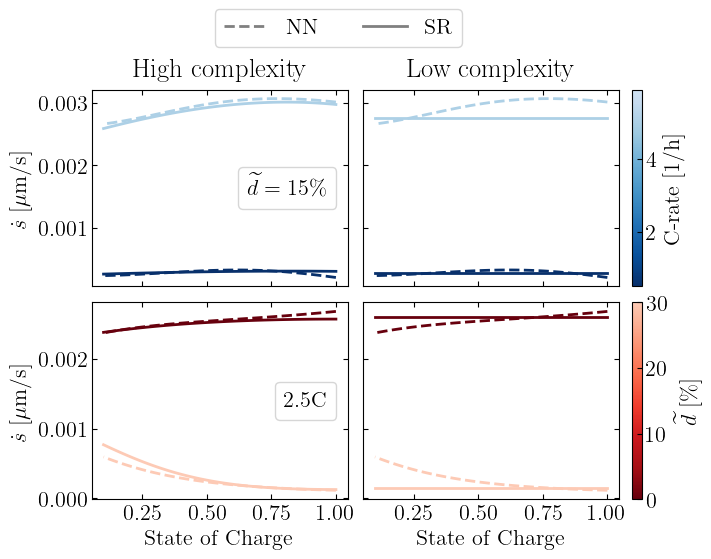

In [22]:
# ––– SR 1505_dark_knight –––
# chosen_SR = {
#     'R0': 11, # JN
#     'R1': 10, # JN
#     'C1': 13, # JN
#     'k': 8,
#     's': 12
# }
# best_SR = {
#     'R0': 14, # JN
#     'R1': 26, # JN,
#     'C1': 18, # JN
#     'k': 14, # JN
#     's': 16 # JH
# }

# ––– SP ––––
chosen_SR = {
    'R0': 8, # JN
    'R1': 8, # JH
    'C1': 7, # JN
    'k': 7, # JH
    's': 6 # JN
}
 
best_SR = {
    'R0': 19, # JN
    'R1': 19, # JH
    'C1': 24, # JN 
    'k': 22, # JH 
    's': 27 # JN
}

sr_model_name = f"SR-chosen-{RUN_ID}"
print(f'SR model name: {sr_model_name}')
# sr_expr = best_SR

# C1_expr = expressions['C1'][sr_expr['C1']]
# R0_expr = expressions['R0'][sr_expr['R0']]
# R1_expr = expressions['R1'][sr_expr['R1']]
# k_expr = expressions['k'][sr_expr['k']]
# sdot_expr = expressions['sdot'][sr_expr['s']]

# R0_func = sp.lambdify(('C', 'd', 'soc'), R0_expr, 'numpy')
# k_func = sp.lambdify(('C', 'd', 'soc'), k_expr, 'numpy')
# R1_func = sp.lambdify(('C', 'd', 'soc'), R1_expr, 'numpy')
# C1_func = sp.lambdify(('C', 'd', 'soc'), C1_expr, 'numpy')
# sdot_func = sp.lambdify(('C', 'd', 'soc', 's'), sdot_expr, 'numpy')



# NN-only
# model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'   # Same
# model_name = '0510_2034_combo_low_c_d_combo_V-dynamic_F-dynamic_702.38min_16h_2500eps.pt'
# model_name = '0511_0931_b4_softplus_combo_full_combo_V-dynamic_F-dynamic_504.37min_16h_2000eps.pt'
# model_name = '0508_2228_DC_DC_V-dynamic_F-dynamic_436.43min_16h_650eps.pt'
# model_name = '0514_0823_b4_combo_combo_V-dynamic_F-dynamic_R0c_C1c_708.27min_16h_2500eps.pt'  # Same
# model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'  # Softplus
el = ['sdot'] # ,'s']
choice = 'both' # 'preferred' or 'simple'
plot_element_grid(el, models='both', fixed_C=2.5, fixed_d=15, sr_choice=choice, c_sweep_vals=np.array([.5,5]), d_sweep_vals=np.linspace(0,30,2))
#plt.savefig(os.path.join('element_figs', f'_grid_R0_R1_C1_nn_{model_name}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join('element_figs/simple_best', f'{el[0]}_{choice}_vs_nn.pdf'), bbox_inches='tight')
plt.show()

# plot_element_grid(['k', 'sdot', 's'], models='nn', fixed_C=2.5, fixed_d=15.0)
# # plt.savefig(os.path.join('element_figs', f'grid_k_sdot_s_nn_{model_name}.pdf'), bbox_inches='tight')
# plt.show()

# plot_element_grid(['tau'], models='nn', fixed_C=2.5, fixed_d=15.0)
# # plt.savefig(os.path.join('element_figs', f'grid_tau_both_{model_name}.pdf'), bbox_inches='tight')
# plt.show()

In [11]:
# Normalization the SR fits expect at their inputs.
# Update these if you retrain SR with a different feature range.
SR_C_NORM = 5.0     # c_rate trained on c_rate / 5
SR_D_NORM = 30.0    # u_per  trained on u_per  / 30

# ── element registry (single source of truth) ──────────────────────────
_ELEM_META = {
    'R0':   (1e3,  r'$R_0$ [m$\Omega$]'),
    'R1':   (1e3,  r'$R_1$ [m$\Omega$]'),
    'C1':   (1e-3, r'$C_1$ [kF]'),
    'tau':  (1.0,  r'$\tau$ [s]'),
    'k':    (1e2,  r'$k$ [MN/µm]'),
    'sdot': (10.0, r'$\dot{s}$ [$\mu$m/s]'),
    's':    (10.0, r'$s$ [$\mu$m]'),
}


def _compute_element(element, c_rate, u_per, soc_t, source='nn', sr_choice='best'):
    """source ∈ {'nn','sr'}. s/sdot always use sdot_nn (no SR variant yet)."""
    # SR functions were trained on normalized inputs; NN handles its own norm.
    if source == 'sr':
        c_arg, u_arg = c_rate / REF_VALUES['C'], u_per / REF_VALUES['d']
        if sr_choice == 'best':
            funcs = {'R0': R0_func, 'R1': R1_func, 'C1': C1_func, 'k': k_func}
        elif sr_choice == 'chosen':
            R0_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R0'][chosen_SR['R0']], 'numpy')
            k_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['k'][chosen_SR['k']], 'numpy')
            R1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['R1'][chosen_SR['R1']], 'numpy')
            C1_func_chosen = sp.lambdify(('C', 'd', 'soc'), expressions['C1'][chosen_SR['C1']], 'numpy')
            funcs = {'R0': R0_func_chosen, 'R1': R1_func_chosen, 'C1': C1_func_chosen, 'k': k_func_chosen}
        else:
            raise ValueError(f"sr_choice must be 'best' or 'chosen', got {sr_choice!r}")
            
    elif source == 'nn':
        c_arg, u_arg = c_rate, u_per
        funcs = {'R0': R0_nn, 'R1': R1_nn, 'C1': C1_nn, 'k': k_nn}
    else:
        raise ValueError(f"source must be 'nn' or 'sr', got {source!r}")

    if element in funcs:
        return funcs[element](c_arg, u_arg, soc_t)

    if element == 'tau':
        return (funcs['R1'](c_arg, u_arg, soc_t) * funcs['C1'](c_arg, u_arg, soc_t))

    if element in ('s', 'sdot'):
        # Integrate s in PHYSICAL units. Then return values in the convention
        # _draw_sweep expects:  NN → physical (×scale_nn at display);
        #                       SR → normalized (×scale_sr×scale_nn at display).
        s_curr = 0.0
        out = []
        dsoc = float(abs(soc_t[1] - soc_t[0]))
        dt = dsoc * 3600.0 / abs(c_rate)

        for soc_val in soc_t:
            if source == 'sr':
                s_in = s_curr / REF_VALUES['s']                       # state → normalized
                ds_norm = float(np.asarray(
                    sdot_func(c_arg, u_arg, soc_val, s_in)).squeeze())
                ds_phys = ds_norm * REF_VALUES['sdot']                # → physical for the integrator
            else:
                ds_phys = float(np.asarray(
                    sdot_nn(c_rate, u_per, soc_val, s_curr)).squeeze())
                if ds_phys < 0:
                    print(f"Negative ds_phys found for soc_val {soc_val}: {ds_phys}")

            if element == 'sdot':
                out.append(ds_phys / REF_VALUES['sdot'] if source == 'sr' else ds_phys)
            s_curr = s_curr + ds_phys * dt
            if s_curr < 0:
                print(f's_curr negative at soc_val {soc_val}: {s_curr}')
            if element == 's':
                out.append(s_curr / REF_VALUES['s'] if source == 'sr' else s_curr)

        return np.asarray(out)

    raise ValueError(f"unknown element {element!r}")


# ── per-axis draw, possibly two sources overlaid ────────────────────────
_LINESTYLE = {'nn': '--', 'sr': '-'}   # NN striped, SR solid

def _draw_sweep(ax, element, *, sweep, fixed, sweep_vals, soc_t,
                cmap_obj, norm, models='nn', sr_choice='best'):
    """models in {'nn','sr','both'}.  When 'both', NN is dashed, SR is solid."""
    scale_nn, ylabel = _ELEM_META[element]
    scale_sr = REF_VALUES[element]

    if models == 'both':
        sources = ['nn', 'sr']
    elif models in ('nn', 'sr'):
        sources = [models]
    else:
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    # If only one source, use solid regardless of which it is
    styles = _LINESTYLE if len(sources) == 2 else {sources[0]: '-'}

    for val in sweep_vals:
        c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        color = cmap_obj(norm(val))
        for src in sources:
            y = _compute_element(element, c_rate, u_per, soc_t, source=src, sr_choice=sr_choice)
            if src == 'nn':
                y_disp = y * scale_nn
            elif src == 'sr':
                y_disp = y * scale_sr * scale_nn

            ax.plot(soc_t.numpy(), y_disp, color=color, lw=2, linestyle=styles[src])

    ax.set_ylabel(ylabel)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')

def _make_cmap(name):
    base = {'Blues': plt.cm.Blues_r, 'Reds': plt.cm.Reds_r}[name]
    return LinearSegmentedColormap.from_list(
        f"{name}_custom", base(np.linspace(0.0, 0.8, 256)))

# ── grid orchestrator ───────────────────────────────────────────────────
def plot_element_grid_negative(elements, *, models='nn',
                      fixed_C=2.5, fixed_d=15.0,
                      d_sweep_vals=None, c_sweep_vals=None,
                      soc=None, figsize=None, sr_choice='best'):
    """
    2  len(elements) grid.
        Top row    : fixed d, sweep C  (Blues, C-rate colorbar)
        Bottom row : fixed C, sweep d  (Reds,  d colorbar)
    models : 'nn' | 'sr' | 'both'.  When 'both', NN is dashed and SR is solid.
    """
    if models not in ('nn', 'sr', 'both'):
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    if d_sweep_vals is None:
        d_sweep_vals = np.linspace(0, 30, 5)
        # d_sweep_vals = np.linspace(-30, 30, 12)
    if c_sweep_vals is None:
        # c_sweep_vals = np.array([-0.5, -1, -2, -3, -4, -5])
        c_sweep_vals = np.linspace(-50.0, 0.0, 6)
    if soc is None:
        soc = np.linspace(1.0, 0.1, 100)
    soc_t = torch.as_tensor(soc, dtype=torch.float32)

    n = len(elements)
    if figsize is None:
        figsize = ((3.5 * n + 1) if n == 1 else (3.5 * n), 5)

    fig, axes = plt.subplots(2, n, figsize=figsize,
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = axes.reshape(2, 1)

    cmap_red, cmap_blue = _make_cmap('Reds'), _make_cmap('Blues')
    norm_d = Normalize(vmin=d_sweep_vals.min(), vmax=d_sweep_vals.max())
    norm_C = Normalize(vmin=c_sweep_vals.min(), vmax=c_sweep_vals.max())

    for j, elem in enumerate(elements):
        _draw_sweep(axes[1, j], elem, sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d, models=models, sr_choice=sr_choice)
        _draw_sweep(axes[0, j], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C, models=models, sr_choice=sr_choice)

    for ax in axes[1, :]:
        ax.set_xlabel('State of Charge')

    sm_d = ScalarMappable(cmap=cmap_red,  norm=norm_d); sm_d.set_array([])
    sm_C = ScalarMappable(cmap=cmap_blue, norm=norm_C); sm_C.set_array([])
    fig.colorbar(sm_d, ax=axes[1, :].tolist(),
                 label=r'$\widetilde{d}$ [\%]', location='right', pad=0.01)
    fig.colorbar(sm_C, ax=axes[0, :].tolist(),
                 label='C-rate [1/h]', location='right', pad=0.01)

    # Fixed-value tags
    axes[1, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'${fixed_C:g}$C')], loc='upper left', frameon=True, handlelength=0, handletextpad=0)
    axes[0, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'$\widetilde{{d}} = {fixed_d:g}\%$')],
        loc='upper left', frameon=True, handlelength=0, handletextpad=0)

    # Linestyle key — only when both sources are overlaid
    if models == 'both':
        axes[0, -1].legend(
            handles=[
                plt.Line2D([0], [0], color='gray', linestyle='--', lw=2, label='NN'),
                plt.Line2D([0], [0], color='gray', linestyle='-',  lw=2, label='SR'+(f' ({sr_choice})' if sr_choice != 'best' else '')),
            ],
            loc='upper left', frameon=True)

    # axes[0, 0].invert_xaxis()
    return fig

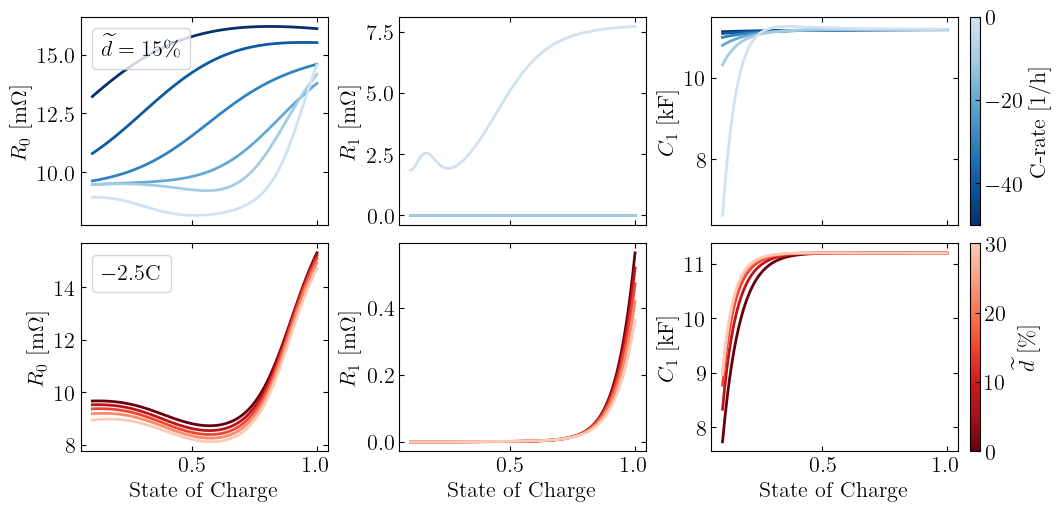

/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_20327/1667119823.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  dt = dsoc * 3600.0 / abs(c_rate)


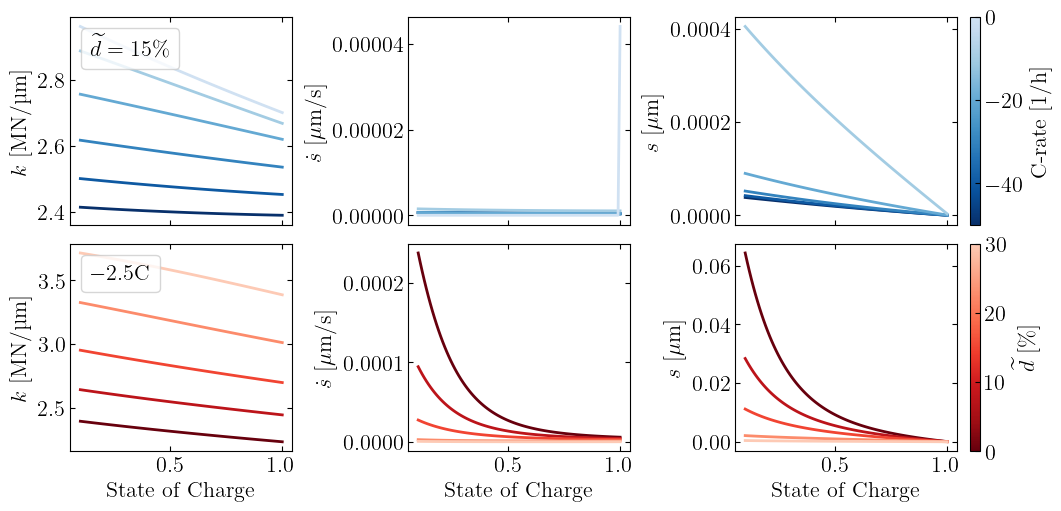

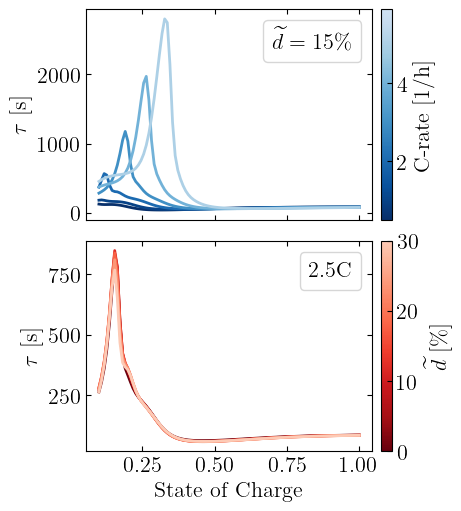

In [12]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'
plot_element_grid_negative(['R0', 'R1', 'C1'], models='nn', fixed_C=-2.5, fixed_d=15.0)
# plt.savefig(os.path.join('element_figs', f'grid_R0_R1_C1_nn_negative_{model_name}.pdf'), bbox_inches='tight')
plt.show()

# plot_element_grid_negative(['R0', 'R1', 'C1'], models='sr', fixed_C=-2.5, fixed_d=15.0)
# # plt.savefig(os.path.join('element_figs', f'grid_R0_R1_C1_both_{model_name}.pdf'), bbox_inches='tight')
# plt.show()

plot_element_grid_negative(['k', 'sdot', 's'], models='nn', fixed_C=-2.5, fixed_d=15.0)
# plt.savefig(os.path.join('element_figs', f'grid_k_sdot_s_nn_negative_{model_name}.pdf'), bbox_inches='tight')
plt.show()

plot_element_grid(['tau'], models='nn', fixed_C=2.5, fixed_d=15.0)
# plt.savefig(os.path.join('element_figs', f'grid_tau_nn_{model_name}.pdf'), bbox_inches='tight')
plt.show()

TypeError: _draw_sweep() got an unexpected keyword argument 'sr_choice'

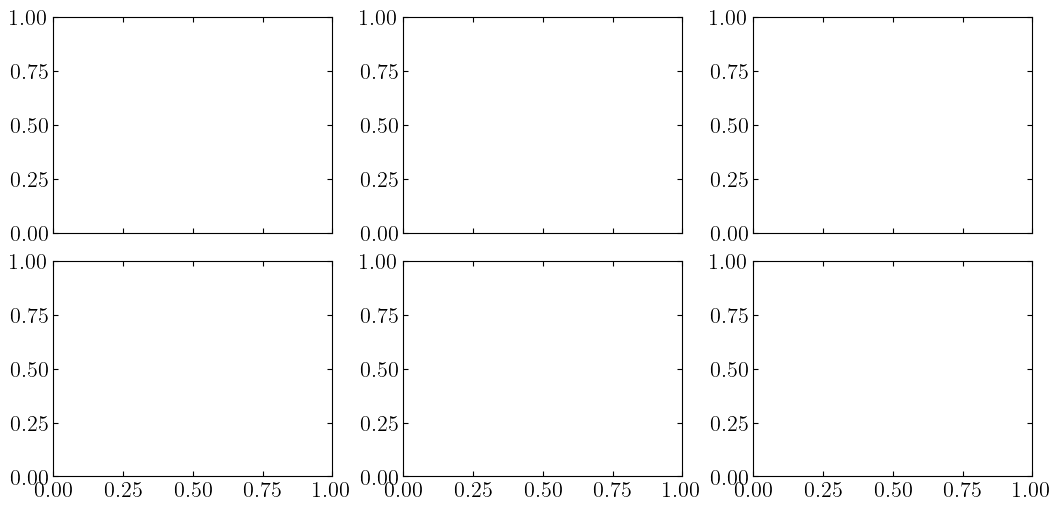

In [13]:
def _make_cmap(name):
    base = {'Blues': plt.cm.Blues_r,
            'Reds':  plt.cm.Reds_r,
            'Greens': plt.cm.Greens_r}[name]
    return LinearSegmentedColormap.from_list(
        f"{name}_custom", base(np.linspace(0.0, 0.8, 256)))

def _draw_sweep(ax, element, *, sweep, fixed, sweep_vals, soc_t,
                cmap_obj, norm, models='nn', linestyle=None):
    scale_nn, ylabel = _ELEM_META[element]
    scale_sr = REF_VALUES[element]

    if models == 'both':
        sources = ['nn', 'sr']
    elif models in ('nn', 'sr'):
        sources = [models]
    else:
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    if linestyle is not None:
        styles = {src: linestyle for src in sources}
    else:
        styles = _LINESTYLE if len(sources) == 2 else {sources[0]: '-'}

    for val in sweep_vals:
        c_rate, u_per = (fixed, val) if sweep == 'u_per' else (val, fixed)
        color = cmap_obj(norm(val))
        for src in sources:
            y = _compute_element(element, c_rate, u_per, soc_t, source=src)
            y_disp = y * scale_nn if src == 'nn' else y * scale_sr * scale_nn
            ax.plot(soc_t.numpy(), y_disp,
                    color=color, lw=2, linestyle=styles[src])

    ax.set_ylabel(ylabel)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')

def plot_element_grid_signed(elements, *, models='nn',
                              fixed_C=2.5, fixed_d=15.0,
                              d_sweep_vals=None,
                              c_sweep_vals_pos=None,
                              c_sweep_vals_neg=None,
                              soc=None, figsize=None):
    """
    Top row : c-rate sweep at fixed_d, with positive C (blue, dashed)
              and negative C (green, solid) overlaid.
    Bottom  : d sweep at fixed_C (red).

    Note: linestyle is repurposed to encode the sign of C, so this variant
    is intended for models='nn' or 'sr' (not 'both').
    """
    if models not in ('nn', 'sr', 'both'):
        raise ValueError(f"models must be 'nn'/'sr'/'both', got {models!r}")

    if d_sweep_vals     is None: d_sweep_vals     = np.linspace(0, 30, 5)
    if c_sweep_vals_pos is None: c_sweep_vals_pos = np.linspace(0.0,  5.0, 6)
    if c_sweep_vals_neg is None: c_sweep_vals_neg = np.linspace(-5.0, 0.0, 6)
    if soc              is None: soc              = np.linspace(1.0, 0.1, 100)
    soc_t = torch.as_tensor(soc, dtype=torch.float32)

    n = len(elements)
    if figsize is None:
        figsize = ((3.5 * n + 1) if n == 1 else (3.5 * n), 5)

    fig, axes = plt.subplots(2, n, figsize=figsize,
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = axes.reshape(2, 1)

    cmap_red   = _make_cmap('Reds')
    cmap_blue  = _make_cmap('Blues')
    cmap_green = _make_cmap('Greens')

    norm_d     = Normalize(vmin=d_sweep_vals.min(),     vmax=d_sweep_vals.max())
    norm_C_pos = Normalize(vmin=c_sweep_vals_pos.min(), vmax=c_sweep_vals_pos.max())
    norm_C_neg = Normalize(vmin=c_sweep_vals_neg.min(), vmax=c_sweep_vals_neg.max())

    for j, elem in enumerate(elements):
        # bottom: d sweep
        _draw_sweep(axes[1, j], elem, sweep='u_per', fixed=fixed_C,
                    sweep_vals=d_sweep_vals, soc_t=soc_t,
                    cmap_obj=cmap_red, norm=norm_d, models=models)
        # top: positive c sweep (blue, dashed)
        _draw_sweep(axes[0, j], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals_pos, soc_t=soc_t,
                    cmap_obj=cmap_blue, norm=norm_C_pos, models=models,
                    linestyle='--')
        # top: negative c sweep (green, solid)
        _draw_sweep(axes[0, j], elem, sweep='c_rate', fixed=fixed_d,
                    sweep_vals=c_sweep_vals_neg, soc_t=soc_t,
                    cmap_obj=cmap_green, norm=norm_C_neg, models=models,
                    linestyle='-')

    for ax in axes[1, :]:
        ax.set_xlabel('State of Charge')

    # colorbars
    sm_d     = ScalarMappable(cmap=cmap_red,   norm=norm_d);     sm_d.set_array([])
    sm_C_pos = ScalarMappable(cmap=cmap_blue,  norm=norm_C_pos); sm_C_pos.set_array([])
    sm_C_neg = ScalarMappable(cmap=cmap_green, norm=norm_C_neg); sm_C_neg.set_array([])

    fig.colorbar(sm_d, ax=axes[1, :].tolist(),
                 label=r'$\widetilde{d}$ [\%]', location='right', pad=0.01)
    fig.colorbar(sm_C_pos, ax=axes[0, :].tolist(),
                 label='C-rate $>0$ [1/h]', location='right', pad=0.01)
    fig.colorbar(sm_C_neg, ax=axes[0, :].tolist(),
                 label='C-rate $<0$ [1/h]', location='right', pad=0.01)

    # fixed-value tags
    axes[1, 0].legend(
        handles=[plt.Line2D([0], [0], color='none', label=fr'${fixed_C:g}$C')],
        loc='upper left', frameon=True, handlelength=0, handletextpad=0)
    axes[0, 0].legend(
        handles=[plt.Line2D([0], [0], color='none',
                            label=fr'$\widetilde{{d}} = {fixed_d:g}\%$')],
        loc='upper left', frameon=True, handlelength=0, handletextpad=0)

    # sign key on the top-right axis
    axes[0, -1].legend(
        handles=[
            plt.Line2D([0], [0], color='steelblue', linestyle='--', lw=2, label='C > 0'),
            plt.Line2D([0], [0], color='seagreen',  linestyle='-',  lw=2, label='C < 0'),
        ],
        loc='upper right', frameon=True)

    return fig

plot_element_grid_negative(['R0', 'R1', 'C1'], models='nn', fixed_C=-2.5, fixed_d=15.0)
# plt.savefig(os.path.join('element_figs', f'grid_R0_R1_C1_nn_negative_{model_name}.pdf'), bbox_inches='tight')
plt.show()